# ML Course Season 2
## Практика: Подбор гиперпараметров и интерпретируемость моделей

В этом ноутбуке мы:
1. Подберём гиперпараметры нескольких моделей с помощью Grid Search и Random Search
2. Настроим Pipeline с совместным подбором препроцессинга и модели
3. Интерпретируем результаты через Permutation Importance, PDP/ICE и SHAP
4. Научимся диагностировать подозрительные признаки

**Датасет:** [Wine Quality](https://scikit-learn.org/stable/datasets/toy_dataset.html) и Breast Cancer Wisconsin (sklearn)

---

## Шаг 1. Импорты и загрузка данных

Загрузим датасет Breast Cancer Wisconsin и познакомимся с ним.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
feature_names = data.feature_names

print(data.DESCR[:600])

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concav


In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Распределение классов в train: {y_train.value_counts().to_dict()}")

Train: (455, 30), Test: (114, 30)
Распределение классов в train: {1: 285, 0: 170}


## Шаг 2. Базовые модели без тюнинга

Обучим несколько моделей с дефолтными параметрами, чтобы иметь точку отсчёта.

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

base_models = {
    'SVM': Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42))]),
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': Pipeline([('scaler', StandardScaler()),
                                    ('clf', LogisticRegression(random_state=42))]),
}

baseline_results = {}

for name, model in base_models.items():
    scores = cross_val_score(model, X_train, y_train, scoring = 'f1_macro')
    baseline_results[name] = (scores.mean(), scores.std())


for name, (mean, std) in baseline_results.items():
    print(f"{name:25s} F1 = {mean:.4f} ± {std:.4f}")

SVM                       F1 = 0.9694 ± 0.0193
RandomForest              F1 = 0.9504 ± 0.0255
LogisticRegression        F1 = 0.9787 ± 0.0139


## Шаг 3. Grid Search для SVM

Подберём гиперпараметры SVM с помощью перебора сетки через Pipeline.

In [4]:
from sklearn.model_selection import GridSearchCV

svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, probability=True)),
])

svm_param_grid = {
    'svm__C' : [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 0.01, 0.001],
    'svm__kernel': ['rbf','linear']
}

svm_grid_search = GridSearchCV(svm_pipe, svm_param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
svm_grid_search.fit(X_train, y_train)

print(f"Лучшие параметры SVM: {svm_grid_search.best_params_}")
print(f"Лучший CV F1: {svm_grid_search.best_score_:.4f}")

Лучшие параметры SVM: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Лучший CV F1: 0.9786


In [5]:
result = pd.DataFrame(svm_grid_search.cv_results_)
columns_to_select = ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
result = result[columns_to_select]

top_10_configs = result.nsmallest(10, 'rank_test_score')

print("Топ-10 конфигураций SVM:")
print(top_10_configs.to_string(index=False))

Топ-10 конфигураций SVM:
                                                         params  mean_test_score  std_test_score  rank_test_score
       {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}         0.978633        0.017581                1
{'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}         0.976215        0.015266                2
   {'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kernel': 'linear'}         0.976215        0.015266                2
  {'svm__C': 0.1, 'svm__gamma': 0.001, 'svm__kernel': 'linear'}         0.976215        0.015266                2
     {'svm__C': 100, 'svm__gamma': 0.001, 'svm__kernel': 'rbf'}         0.976157        0.016975                5
      {'svm__C': 10, 'svm__gamma': 0.001, 'svm__kernel': 'rbf'}         0.971340        0.016281                6
     {'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}         0.969357        0.019323                7
    {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}

## Шаг 4. Random Search для RandomForest

Теперь подберём гиперпараметры RandomForest с помощью случайного поиска.

In [6]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, loguniform

rf_param_dist = {
    'n_estimators': randint(50, 500),                            
    'max_depth': [randint(2, 20), None],                        
    'min_samples_split': randint(2, 20),                        
    'max_features': ['sqrt', 'log2', 0.5] 
}

rf_random_search = RandomizedSearchCV(RandomForestClassifier(), rf_param_dist,
                            scoring='f1_macro', random_state=42, n_jobs=-1)

rf_random_search.fit(X_train, y_train)

print(f"Лучшие параметры RF: {rf_random_search.best_params_}")
print(f"Лучший CV F1: {rf_random_search.best_score_:.4f}")

Лучшие параметры RF: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 363}
Лучший CV F1: 0.9577


## Шаг 5. Сравнение результатов

Сравним: baseline vs Grid Search vs Random Search. И проведём финальную оценку на тесте.

In [7]:
from sklearn.metrics import classification_report

best_svm = svm_grid_search.best_estimator_
y_pred_svm = best_svm.predict(X_test)

best_rf = rf_random_search.best_estimator_
y_pred_rf = best_rf.predict(X_test)

scr_svm = cross_val_score(best_svm, X_train, y_train, scoring = 'f1_macro')
scr_rf = cross_val_score(best_rf, X_train, y_train, scoring = 'f1_macro')

base_models['SVM'].fit(X_train, y_train)
y_pred_base_svm = base_models['SVM'].predict(X_test)

base_models['RandomForest'].fit(X_train, y_train)
y_pred_base_rf = base_models['RandomForest'].predict(X_test)


for_results = [baseline_results['SVM'], (scr_svm.mean(), scr_svm.std()),
                     baseline_results['RandomForest'], (scr_rf.mean(), scr_rf.std())]

def get_met(arr, y_pred):
    return{
        'CV F1 (mean±std)': f"{arr[0]:.2f}±{arr[1]:.2f}",
        'Test F1': f"{f1_score(y_test, y_pred):.2f}"
    }

results = pd.DataFrame([
    get_met(for_results[0], y_pred_base_svm),
    get_met(for_results[1], y_pred_svm),
    get_met(for_results[2], y_pred_base_rf),
    get_met(for_results[3], y_pred_rf)
], index=['SVM baseline', 'SVM Grid Search', 'RF baseline', 'RF Random Search'])


display(results)

,CV F1 (mean±std),Test F1
SVM baseline,0.97±0.02,0.99
SVM Grid Search,0.98±0.02,0.99
RF baseline,0.95±0.03,0.97
RF Random Search,0.96±0.02,0.97


In [8]:
print("SVM Baseline")
print(classification_report(y_test, y_pred_base_svm))

print("SVM Grid Search")
print(classification_report(y_test, y_pred_svm))

print("RF Baseline")
print(classification_report(y_test, y_pred_base_rf))

print("RF Random Search")
print(classification_report(y_test, y_pred_rf))

SVM Baseline
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

SVM Grid Search
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

RF Baseline
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96

## Шаг 6. Permutation Importance

Посмотрим, какие признаки важны для лучшей модели.

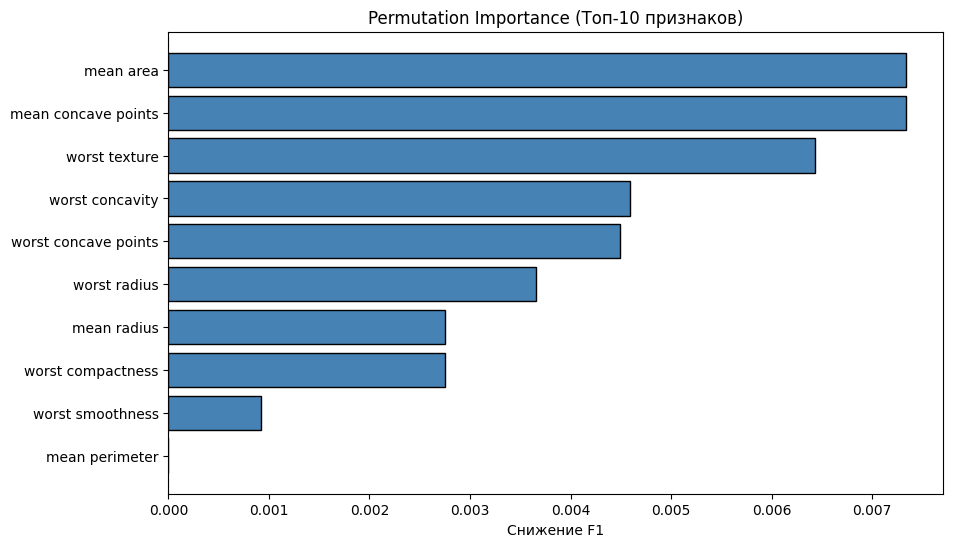

In [9]:
from sklearn.inspection import permutation_importance

pi_result = permutation_importance(best_rf, X_test, y_test,
                                   n_repeats=10, random_state=42, scoring='f1_macro')

idx = pi_result.importances_mean.argsort()[::-1]
top_10_idx = idx[:10]

plt.figure(figsize=(10, 6))
plt.barh(X_test.columns[top_10_idx][::-1], pi_result.importances_mean[top_10_idx][::-1],
         color='steelblue', edgecolor='black')
plt.axvline(0, color='red', linestyle='--', linewidth=0.8)
plt.xlabel('Снижение F1')
plt.title('Permutation Importance (Топ-10 признаков)')
plt.show()

In [10]:
rf_importances = best_rf.feature_importances_

comparison = pd.DataFrame({
    'feature': X_test.columns,
    'permutation': pi_result.importances_mean,
    'rf_builtin': rf_importances
})

top5_pi = comparison.nlargest(5, 'permutation')[['feature', 'permutation']]
top5_rf = comparison.nlargest(5, 'rf_builtin')[['feature', 'rf_builtin']]

print("Топ-5 по Permutation Importance:\n")
print(top5_pi.to_string(index=False))

print("\n\nТоп-5 по встроенной важности RF:\n")
print(top5_rf.to_string(index=False))

Топ-5 по Permutation Importance:

             feature  permutation
           mean area     0.007340
 mean concave points     0.007332
       worst texture     0.006430
     worst concavity     0.004593
worst concave points     0.004490


Топ-5 по встроенной важности RF:

             feature  rf_builtin
worst concave points    0.126197
     worst perimeter    0.125386
          worst area    0.117954
        worst radius    0.107814
 mean concave points    0.102725


Порядок важности у `Permutation Importance` и встроенного `feature_importances_ RandomForest` не совпадает. Это может быть из-за корреляции признаков(встроенная важность «делит» вклад между коррелирующими признаками, а `PI` оценивает каждый независимо)
 

- Если у признака высокий `PI`, но низкая встроенная важность, значит признак критичен для обобщения на тесте
- Если у признака низкий `PI`, но высокая встроенная важность, значит признак мог быть полезен для подгонки под тренировочные данные (переобучение), но не помогает на новых данных, либо он коррелирует с более сильным признаком.

## Шаг 7. PDP и ICE-кривые

Визуализируем эффект наиболее важных признаков.

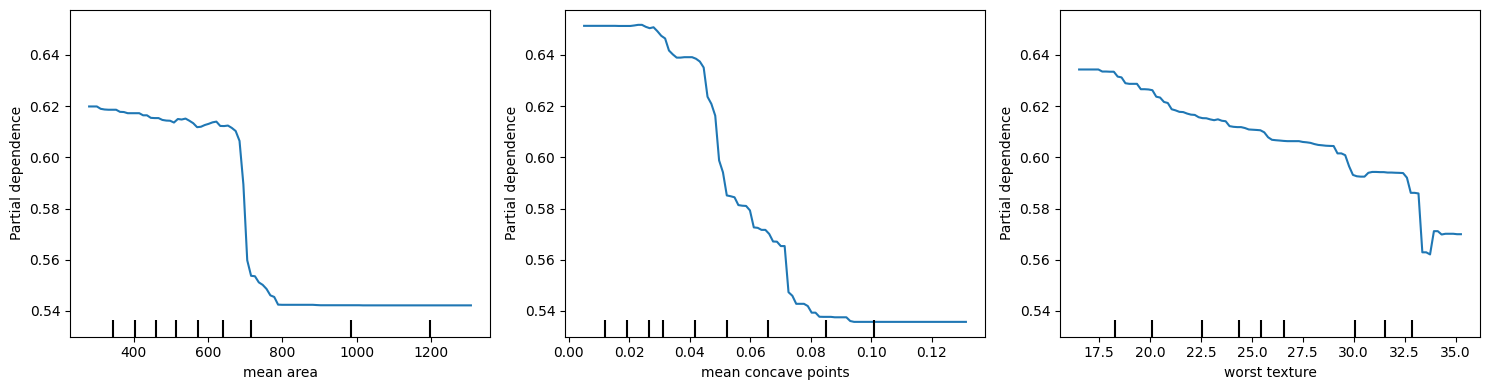

In [11]:
from sklearn.inspection import PartialDependenceDisplay

top3_idx = comparison.nlargest(3, 'permutation')['feature']

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
PartialDependenceDisplay.from_estimator(
		best_rf, X_test,
		features=top3_idx, 
		kind='average',   
        ax=ax        
)
plt.tight_layout()
plt.show()

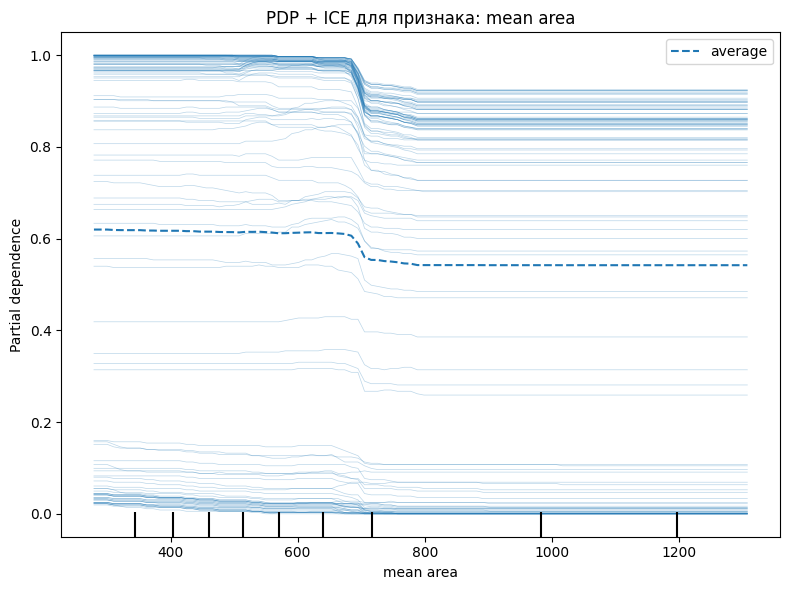

In [12]:
most_important_feature = comparison.nlargest(1, 'permutation')['feature'].iloc[0]
fig, ax = plt.subplots(figsize=(8, 6))
PartialDependenceDisplay.from_estimator(
    best_rf, 
    X_test,
    features=[most_important_feature],
    kind='both',   # PDP + все ICE кривые
    ax=ax
)
plt.title(f'PDP + ICE для признака: {most_important_feature}')
plt.tight_layout()
plt.show()

Эффект неоднородный, так как на графике видно расхождение индивидуальных кривых (`ICE`), что указывает на зависимость влияния признака от значений других переменных в данных.

## Шаг 8. SHAP

Интерпретируем модель с помощью SHAP — глобально и локально.

In [13]:
import shap

explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

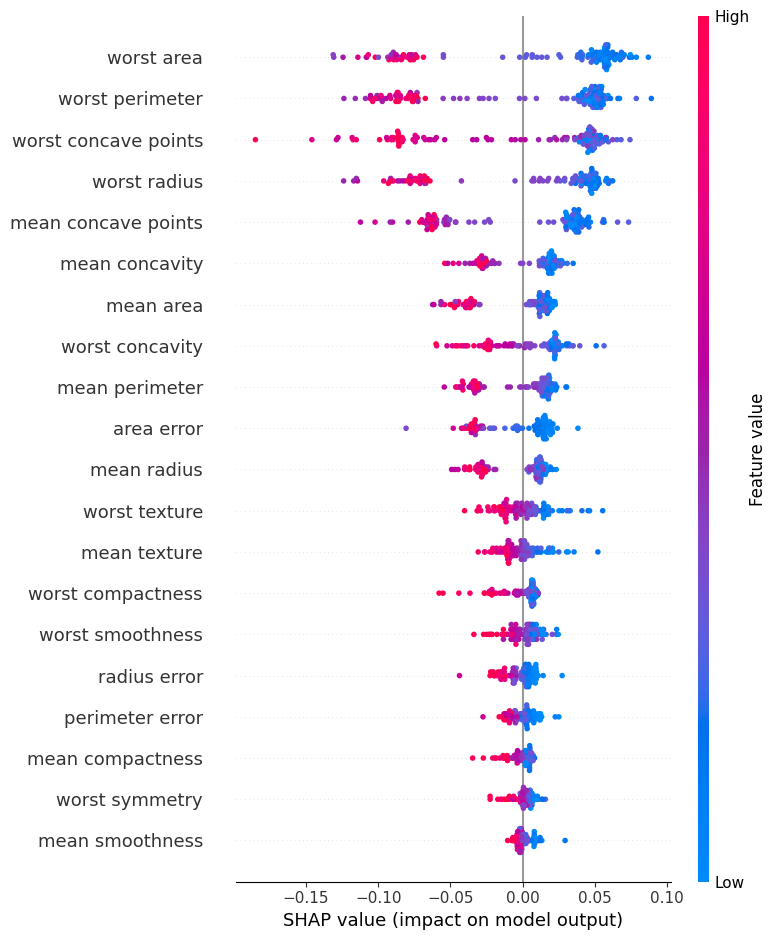

In [14]:
shap_to_plot = shap_values[:, :, 1]

shap.summary_plot(
    shap_to_plot,  
    X_test,
    feature_names=X_test.columns,
    plot_type='dot'
)

1. `worst concave point`, `worst radius`, `worst perimetr` наиболее важные по SHAP
2. Полного совпадение SHAP c PI нет, хотя есть некоторые пересечения 

Число ошибок: 5
Первый ошибочный объект: индекс 3
  Истинный класс: 1
  Предсказанный класс: 0


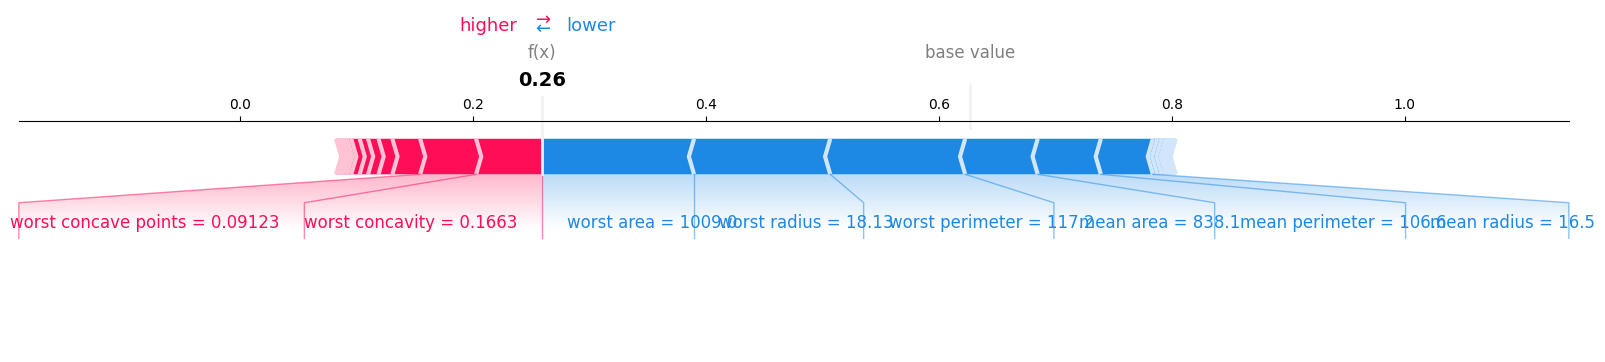

In [15]:
y_pred_test = best_rf.predict(X_test)
errors = np.where(y_pred_test != y_test)[0]

print(f"Число ошибок: {len(errors)}")

if len(errors) > 0:
    error_idx = errors[0]
    print(f"Первый ошибочный объект: индекс {error_idx}")
    print(f"  Истинный класс: {y_test.iloc[error_idx]}")
    print(f"  Предсказанный класс: {y_pred_test[error_idx]}")
    

    shap.force_plot(
        explainer.expected_value[1],           # базовое значение для класса 1
        shap_values[:, :, 1][error_idx],       # SHAP-значения для класса 1, один объект
        X_test.iloc[error_idx],                # признаки этого объекта
        feature_names=X_test.columns.tolist(),
        matplotlib=True
    )

В ошибке виноваты признаки, которые помечены синим цветом на графике(`worst area`, `worst radius` и тд).

Модель ошиблась, потому что для этого объекта размеры опухоли оказались больше характерными для доброкачественных опухолей, несмотря на то, что на самом деле опухоль злокачественная.

## Шаг 9. Диагностика подозрительных признаков

Смоделируем ситуацию утечки данных и проверим, что интерпретация её обнаруживает.

In [16]:
# Добавим два «подозрительных» признака:
# 1. leaky_feature: почти полностью совпадает с таргетом + шум
# 2. random_feature: случайный шум, не связан с таргетом

np.random.seed(42)
X_train_ext = X_train.copy()
X_test_ext = X_test.copy()

X_train_ext['leaky_feature'] = y_train + np.random.normal(0, 0.1, len(y_train))
X_test_ext['leaky_feature'] = y_test + np.random.normal(0, 0.1, len(y_test))

X_train_ext['random_feature'] = np.random.randn(len(y_train))
X_test_ext['random_feature'] = np.random.randn(len(y_test))

print("Добавлены признаки: leaky_feature, random_feature")
print(X_train_ext.tail())

Добавлены признаки: leaky_feature, random_feature
     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
184        15.28         22.41           98.92      710.6          0.09057   
300        19.53         18.90          129.50     1217.0          0.11500   
509        15.46         23.95          103.80      731.3          0.11830   
230        17.05         19.08          113.40      895.0          0.11410   
474        10.88         15.62           70.41      358.9          0.10070   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
184            0.1052         0.05375              0.03263         0.1727   
300            0.1642         0.21970              0.10620         0.1792   
509            0.1870         0.20300              0.08520         0.1807   
230            0.1572         0.19100              0.10900         0.2131   
474            0.1069         0.05115              0.01571         0.1861   

     mean fractal 

Тест F1 с leaky признаком: 1.000


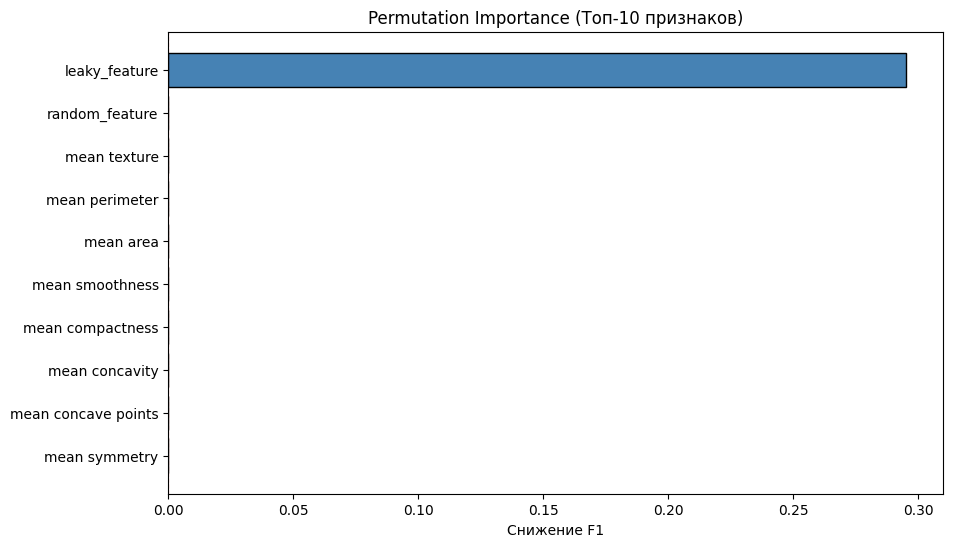

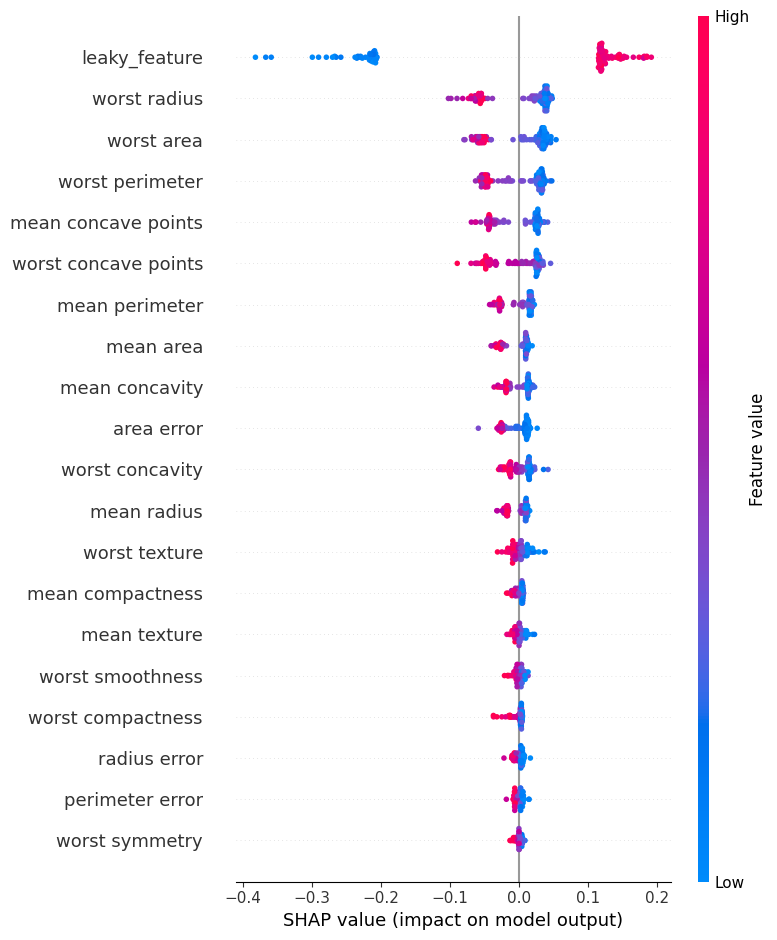

In [17]:
rf_ext = RandomForestClassifier(**rf_random_search.best_params_, random_state=42)

rf_ext.fit(X_train_ext, y_train)
y_pred_ext = rf_ext.predict(X_test_ext)
print(f"Тест F1 с leaky признаком: {f1_score(y_test, y_pred_ext, average='macro'):.3f}")

feature_names_ext = list(feature_names) + ['leaky_feature', 'random_feature']
pi_ext = permutation_importance(
    rf_ext, X_test_ext, y_test,
    n_repeats=10, random_state=42, scoring='f1_macro', n_jobs=-1
)

idx_ext = pi_ext.importances_mean.argsort()[::-1]
top_10_idx_ext = idx_ext[:10]

plt.figure(figsize=(10, 6))
plt.barh(X_test_ext.columns[top_10_idx_ext][::-1], pi_ext.importances_mean[top_10_idx_ext][::-1],
         color='steelblue', edgecolor='black')
plt.axvline(0, color='red', linestyle='--', linewidth=0.8)
plt.xlabel('Снижение F1')
plt.title('Permutation Importance (Топ-10 признаков)')
plt.show()

explainer_ext = shap.TreeExplainer(rf_ext)
shap_values_ext = explainer_ext.shap_values(X_test_ext)

shap.summary_plot(shap_values_ext[:, :, 1], X_test_ext, feature_names=X_test_ext.columns)

1. `leaky_feature` показан как самый важный признак с огромным отрывом, при перемешивании этого признака 
    метрика (F1) резко падает, так как модель теряет доступ к информации, почти идеально коррелирующей с 
    таргетом `PI` показывает очень высокое значение importance для этого признака
    
2. `leaky_feature` на первом месте в `summary_plot`, у него широкий разброс SHAP values, 
    - Высокие значения leaky_feature → положительные SHAP values → предсказание класса 1
    - Низкие значения → отрицательные SHAP values → предсказание класса 0

3. Шумовые признаки (`random_feature`) имеют importance ≈ 0 и маленькими SHAP values 

## Шаг 10. Сводная таблица и итоги

Соберём все результаты и сформулируем выводы.

In [18]:
results_conclusion = results.copy()
pd.set_option('display.max_colwidth', None)

results_conclusion['Выводы'] = [
    'Показал отличную базовую точность, датасет хорошо разделяется линейно',
    'Grid Search дал небольшой прирост на CV (+0.01), на тесте результат стабилен, переобучения нет',
    'RF baseline немного уступает SVM, для небольших табличных данных SVM часто эффективнее',
    'Random Search улучшил RF, но разрыв с SVM сохраняется'
]

display(results_conclusion)

,CV F1 (mean±std),Test F1,Выводы
SVM baseline,0.97±0.02,0.99,"Показал отличную базовую точность, датасет хорошо разделяется линейно"
SVM Grid Search,0.98±0.02,0.99,"Grid Search дал небольшой прирост на CV (+0.01), на тесте результат стабилен, переобучения нет"
RF baseline,0.95±0.03,0.97,"RF baseline немного уступает SVM, для небольших табличных данных SVM часто эффективнее"
RF Random Search,0.96±0.02,0.97,"Random Search улучшил RF, но разрыв с SVM сохраняется"


1. Тюнинг поднял F1 у SVM и RF +0.01 на CV, на Test без изменений

2. Топ-признаки у PI и SHAP не совпадают полностью из-за корреляция признаков и разного принципа оценки (
    - `PI` измеряет, насколько упадёт метрика, если перемешать значения признака — оценивает реальный вклад в предсказание на тесте
    - `SHAP` основан на вкладе признака в деревья решений)
    
3. Если не использовать Pipeline, риск data leakage при масштабировании, Pipeline гарантирует, что 
   препроцессинг применяется корректно внутри  каждой итерации CV, предотвращая утечку информации

4. Как бы использовали PI и SHAP в реальном проекте:  
    - `PI`:
        - Финальная валидация важности признаков на отложенной выборке
        - Feature selection: удаление слабых признаков для упрощения модели
        - Детекция data leakage: подозрительно высокий PI → проверка на утечку (как в Шаге 9)
    - `SHAP`: 
        - Локальная интерпретация: почему модель ошиблась на конкретном объекте (force_plot)
        - Глобальное понимание: какие признаки и как влияют на предсказания (summary_plot, dependence_plot)

## Шаг 11. (Бонус) Bayesian Optimization с Optuna

Если осталось время — сравните Random Search и Optuna по скорости сходимости.

Запуск оптимизации Optuna...


Best trial: 41. Best value: 0.960032: 100%|██████████| 50/50 [00:49<00:00,  1.00it/s]

Лучший результат Optuna: 0.9600
Лучшие параметры: {'n_estimators': 161, 'max_depth': 13, 'min_samples_split': 3, 'max_features': 0.5}


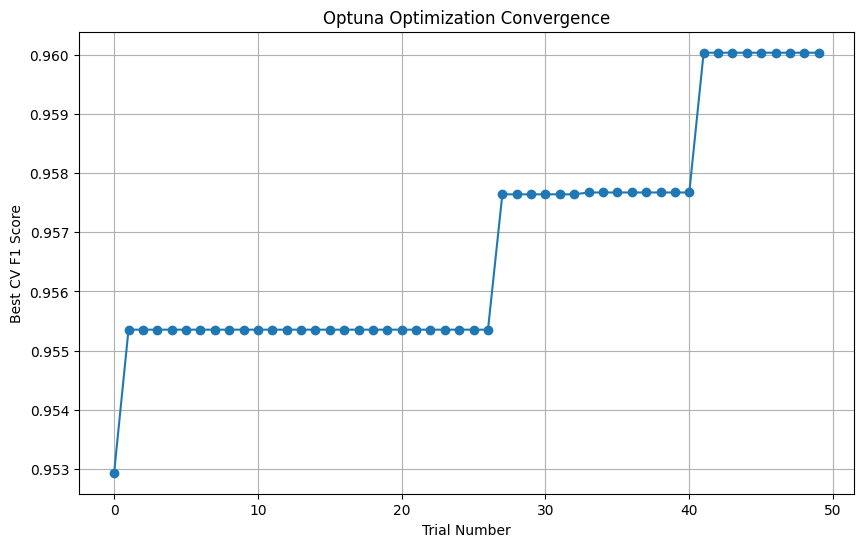

In [19]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):

    n_estimators = trial.suggest_int('n_estimators', 50, 500)
    max_depth = trial.suggest_categorical('max_depth', list(range(2, 21)) + [None])
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5])
    
    clf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        max_features=max_features,
        random_state=42
    )
    
    score = cross_val_score(clf, X_train, y_train, cv=5, scoring='f1_macro').mean()
    
    return score

study = optuna.create_study(direction='maximize')

print("Запуск оптимизации Optuna...")
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"Лучший результат Optuna: {study.best_value:.4f}")
print(f"Лучшие параметры: {study.best_params}")

best_values = []
current_best = -float('inf')

for trial in study.trials:
    if trial.value is not None:
        if trial.value > current_best:
            current_best = trial.value
        best_values.append(current_best)
    else:
        if best_values:
            best_values.append(best_values[-1])
        else:
            best_values.append(0)

plt.figure(figsize=(10, 6))
plt.plot(range(len(best_values)), best_values, marker='o', linestyle='-')
plt.title('Optuna Optimization Convergence')
plt.xlabel('Trial Number')
plt.ylabel('Best CV F1 Score')
plt.grid(True)
plt.show()